# API Usage Demonstration

This notebook demonstrates the core functionalities of the `CloudPickle.py` wrapper, focusing on:
1. Fetching Bitcoin price data from CoinGecko (native API interaction via wrapper).
2. Serializing and deserializing Python objects (DataFrames and functions) using `cloudpickle` through the wrapper.
3. Performing basic time series analysis (moving average, trend) using utility functions.
4. Visualizing data.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import os

try:
    from CloudPickle_utils import (
        fetch_bitcoin_price_history,
        serialize_object,
        deserialize_object,
        calculate_moving_average,
        simple_trend_analysis,
        plot_price_data
    )
    print("CloudPickle_utils.py loaded successfully.")
except ImportError as e:
    print(f"ImportError: {e}. Make sure CloudPickle_utils.py is in the current directory or your PYTHONPATH.")
    # Fallback if running in an environment where direct import might be tricky initially


CloudPickle_utils.py loaded successfully.


# Data Ingestion: Fetching Bitcoin Price Data

We use `Workspace_bitcoin_price_history` to get data from CoinGecko. This function handles the call to the native API endpoint `/coins/bitcoin/market_chart`.


In [5]:
print("Fetching Bitcoin price data for the last 24 hours (hourly data)...")
btc_data_hourly = fetch_bitcoin_price_history(days=1, currency='usd')

if btc_data_hourly is not None and not btc_data_hourly.empty:
    print("\nSuccessfully fetched hourly Bitcoin data:")
    display(btc_data_hourly.head())
    print(f"\nShape of data: {btc_data_hourly.shape}")
else:
    print("\nFailed to fetch hourly Bitcoin data or no data returned.")


Fetching Bitcoin price data for the last 24 hours (hourly data)...
Fetching Bitcoin data from CoinGecko: days=1, currency=usd
Successfully fetched 288 data points.

Successfully fetched hourly Bitcoin data:


,price
timestamp,
2025-05-15 03:46:34.281,102910.556153
2025-05-15 03:50:29.578,102896.496780
2025-05-15 03:55:39.447,102864.209082
2025-05-15 04:00:58.095,102823.325586
2025-05-15 04:06:21.120,102815.835357



Shape of data: (288, 1)


In [6]:
print("\nFetching Bitcoin price data for the last 7 days (daily data)...")
btc_data_daily = fetch_bitcoin_price_history(days=7, currency='usd')

if btc_data_daily is not None and not btc_data_daily.empty:
    print("\nSuccessfully fetched daily Bitcoin data:")
    display(btc_data_daily.head())
    print(f"\nShape of data: {btc_data_daily.shape}")
else:
    print("\nFailed to fetch daily Bitcoin data or no data returned.")



Fetching Bitcoin price data for the last 7 days (daily data)...
Fetching Bitcoin data from CoinGecko: days=7, currency=usd
Successfully fetched 168 data points.

Successfully fetched daily Bitcoin data:


,price
timestamp,
2025-05-09 04:04:17.844,102431.385938
2025-05-09 05:04:42.226,102735.235420
2025-05-09 06:04:20.120,102936.707481
2025-05-09 07:37:44.828,103654.432069
2025-05-09 08:04:28.886,103775.851994



Shape of data: (168, 1)


# Data Serialization and Deserialization with `cloudpickle`

The wrapper functions `serialize_object` and `deserialize_object` use `cloudpickle` internally.


## Serializing and Deserializing a DataFrame


In [7]:
DF_SERIALIZATION_FILE = 'btc_daily_data_api_demo.pkl'

if btc_data_daily is not None and not btc_data_daily.empty:
    print(f"\nSerializing the daily DataFrame to {DF_SERIALIZATION_FILE}...")
    serialize_object(btc_data_daily, DF_SERIALIZATION_FILE)

    print(f"\nDeserializing the DataFrame from {DF_SERIALIZATION_FILE}...")
    deserialized_btc_data = deserialize_object(DF_SERIALIZATION_FILE)

    if deserialized_btc_data is not None:
        print("\nVerifying deserialized data (first 5 rows):")
        display(deserialized_btc_data.head())
        if btc_data_daily.equals(deserialized_btc_data):
            print("Serialization and deserialization successful: DataFrames are identical.")
        else:
            print("Warning: Deserialized DataFrame differs from original.")
    else:
        print("Deserialization failed.")
    # Clean up the created file
    if os.path.exists(DF_SERIALIZATION_FILE):
        try:
            os.remove(DF_SERIALIZATION_FILE)
            print(f"Cleaned up {DF_SERIALIZATION_FILE}")
        except Exception as e:
            print(f"Could not clean up {DF_SERIALIZATION_FILE}: {e}")
else:
    print("\nSkipping DataFrame serialization demo as daily data was not fetched.")



Serializing the daily DataFrame to btc_daily_data_api_demo.pkl...
Object successfully serialized to btc_daily_data_api_demo.pkl

Deserializing the DataFrame from btc_daily_data_api_demo.pkl...
Object successfully deserialized from btc_daily_data_api_demo.pkl

Verifying deserialized data (first 5 rows):


,price
timestamp,
2025-05-09 04:04:17.844,102431.385938
2025-05-09 05:04:42.226,102735.235420
2025-05-09 06:04:20.120,102936.707481
2025-05-09 07:37:44.828,103654.432069
2025-05-09 08:04:28.886,103775.851994


Serialization and deserialization successful: DataFrames are identical.
Cleaned up btc_daily_data_api_demo.pkl


## Serializing and Deserializing a Function

`cloudpickle` excels at serializing more complex Python objects like functions, including those defined locally or with closures. Here, we'll serialize one of our utility functions.


In [8]:
FUNC_SERIALIZATION_FILE = 'sma_calculator_func_api_demo.pkl'
function_to_serialize = calculate_moving_average # This is the function object itself

print(f"\nSerializing the 'calculate_moving_average' function to {FUNC_SERIALIZATION_FILE}...")
serialize_object(function_to_serialize, FUNC_SERIALIZATION_FILE)

print(f"\nDeserializing the function from {FUNC_SERIALIZATION_FILE}...")
deserialized_func = deserialize_object(FUNC_SERIALIZATION_FILE)

if deserialized_func is not None:
    print(f"Successfully deserialized function: {deserialized_func.__name__}")
    # Test the deserialized function
    if btc_data_daily is not None and not btc_data_daily.empty:
        print("\nApplying the deserialized SMA function to daily data (window=2)...")
        df_processed_by_deserialized_func = deserialized_func(btc_data_daily.copy(), 2) # window_size = 2
        if df_processed_by_deserialized_func is not None:
            display(df_processed_by_deserialized_func.head())
        else:
            print("Deserialized function did not return a DataFrame.")
    else:
        print("\nSkipping test of deserialized function as daily data was not fetched.")
    # Clean up
    if os.path.exists(FUNC_SERIALIZATION_FILE):
        try:
            os.remove(FUNC_SERIALIZATION_FILE)
            print(f"Cleaned up {FUNC_SERIALIZATION_FILE}")
        except Exception as e:
            print(f"Could not clean up {FUNC_SERIALIZATION_FILE}: {e}")
else:
    print(f"Failed to deserialize the function from {FUNC_SERIALIZATION_FILE}.")



Serializing the 'calculate_moving_average' function to sma_calculator_func_api_demo.pkl...
Object successfully serialized to sma_calculator_func_api_demo.pkl

Deserializing the function from sma_calculator_func_api_demo.pkl...
Object successfully deserialized from sma_calculator_func_api_demo.pkl
Successfully deserialized function: calculate_moving_average

Applying the deserialized SMA function to daily data (window=2)...


,price,sma_2
timestamp,,
2025-05-09 04:04:17.844,102431.385938,102431.385938
2025-05-09 05:04:42.226,102735.235420,102583.310679
2025-05-09 06:04:20.120,102936.707481,102835.971451
2025-05-09 07:37:44.828,103654.432069,103295.569775
2025-05-09 08:04:28.886,103775.851994,103715.142032


Cleaned up sma_calculator_func_api_demo.pkl


# Basic Time Series Analysis Functions


## Calculating Moving Average


In [9]:
btc_data_with_sma = None 
if btc_data_daily is not None and not btc_data_daily.empty:
    window = 3 # 3-day moving average for daily data
    print(f"\nCalculating {window}-day Simple Moving Average (SMA) for daily data...")
    btc_data_with_sma = calculate_moving_average(btc_data_daily.copy(), window_size=window)
    if btc_data_with_sma is not None:
        display(btc_data_with_sma.head())
    else:
        print("SMA calculation resulted in None.")
else:
    print("\nSkipping SMA calculation as daily data was not fetched.")



Calculating 3-day Simple Moving Average (SMA) for daily data...


,price,sma_3
timestamp,,
2025-05-09 04:04:17.844,102431.385938,102431.385938
2025-05-09 05:04:42.226,102735.235420,102583.310679
2025-05-09 06:04:20.120,102936.707481,102701.109613
2025-05-09 07:37:44.828,103654.432069,103108.791657
2025-05-09 08:04:28.886,103775.851994,103455.663848


## Simple Trend Analysis


In [10]:
if btc_data_daily is not None and not btc_data_daily.empty:
    print("\nPerforming simple trend analysis on daily data...")
    trend = simple_trend_analysis(btc_data_daily)
    print(trend)
else:
    print("\nSkipping trend analysis as daily data was not fetched.")



Performing simple trend analysis on daily data...
Simple Trend: Uptrend (Change: 1.70%)


# Plotting Data



Plotting daily Bitcoin price and 3-day SMA...
Plot successfully saved to btc_plot_20250516_034954.png
Plot saved as btc_plot_20250516_034954.png


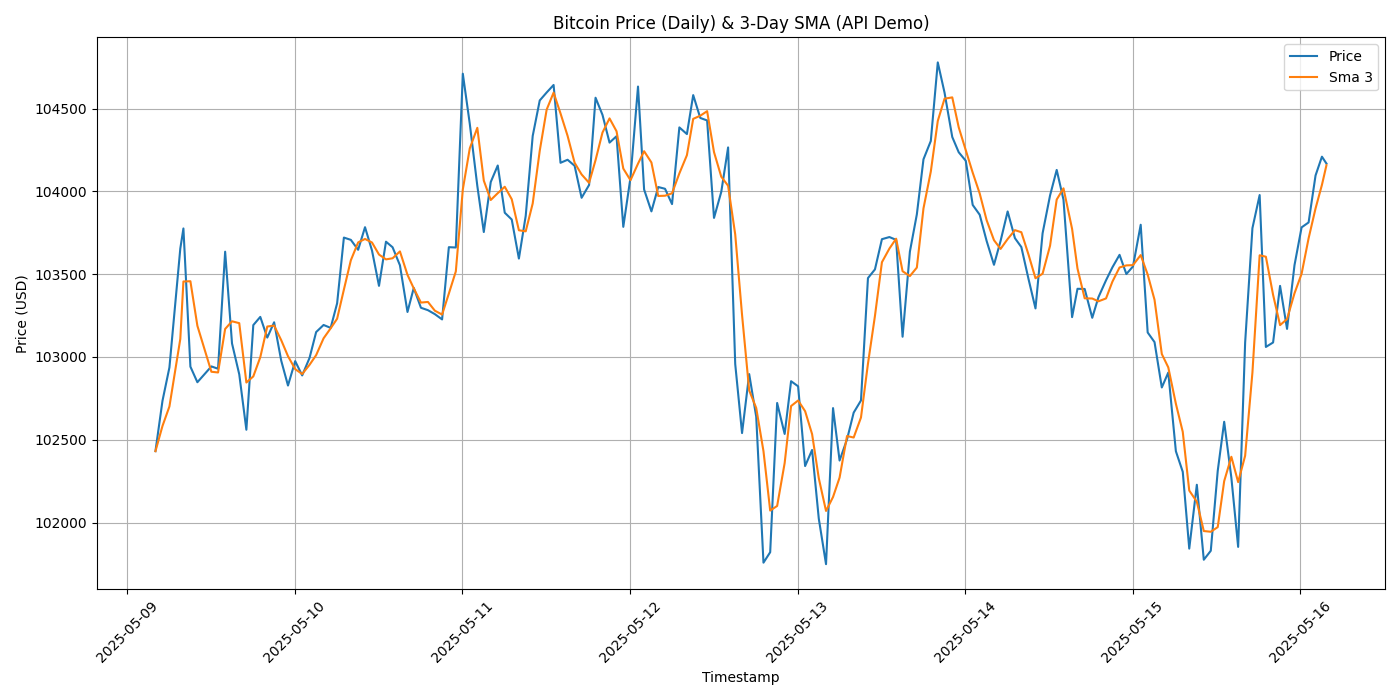

Cleaned up btc_plot_20250516_034954.png


In [11]:
plot_filename = None # Initialize
if btc_data_with_sma is not None and not btc_data_with_sma.empty:
    print("\nPlotting daily Bitcoin price and 3-day SMA...")
    plot_filename = plot_price_data(btc_data_with_sma, 
                                    title="Bitcoin Price (Daily) & 3-Day SMA (API Demo)",
                                    columns_to_plot=['price', f'sma_3']) # Specify columns
elif btc_data_daily is not None and not btc_data_daily.empty:
    print("\nPlotting daily Bitcoin price (SMA not calculated or available)...")
    plot_filename = plot_price_data(btc_data_daily, title="Bitcoin Price (Daily) - API Demo")
else:
    print("\nSkipping plotting as no data was available.")

if plot_filename:
    print(f"Plot saved as {plot_filename}")
    display(Image(filename=plot_filename))
    # Clean up the plot file
    if os.path.exists(plot_filename):
        try:
            os.remove(plot_filename)
            print(f"Cleaned up {plot_filename}")
        except Exception as e:
            print(f"Could not clean up {plot_filename}: {e}")
elif btc_data_with_sma is not None or btc_data_daily is not None: # Only print if we attempted to plot
     print("Plotting failed or DataFrame was empty.")


This notebook demonstrated the core functionalities of the `BTC_Analysis_utils.py` wrapper, covering data fetching, serialization/deserialization of data and functions (via `cloudpickle`), basic analysis, and plotting.
